In [1]:
import cdms
import numpy as np
import os, sys 
import ROOT
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import supercuts
import glob

import matplotlib.pyplot as plt
%matplotlib inline

#CDMS = os.environ["CDMS"] # set in .bash_profile
#stylesheet = os.path.join(CDMS,"scripts","stylesheets","blues.mplstyle")
#plt.style.use(stylesheet)

#sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
#import setup

Welcome to JupyROOT 6.28/10


In [2]:
from scipy.optimize import curve_fit
from uncertainties import ufloat
import math

def func(x, a, b):
    return a*x + b

def fit_logPulse(x, y, start, stop):
    popt, pcov = curve_fit(func, x[start:stop], y[start:stop])
    return popt[0], np.sqrt(np.diag(pcov))[0], popt[1], np.sqrt(np.diag(pcov))[1]

def str_with_err(value, error):
    digits = -int(math.floor(math.log10(error)))
    return "{0:.{2}f}({1:.0f})".format(value, error*10**digits, digits)

In [3]:
DMCfiles = np.sort(glob.glob('/scratch/perry/Ge71_Kshell_0V_100kEvents/test/Ge71_Kshell_51251002_00000?.root'))

In [20]:
mczipFrame = CDataFrame('G4SimDir/mczip0', DMCfiles)
mczip = mczipFrame.Filter('Charge==0').AsNumpy(['EventNum', 'KE', 'Yield', 'Weight'])

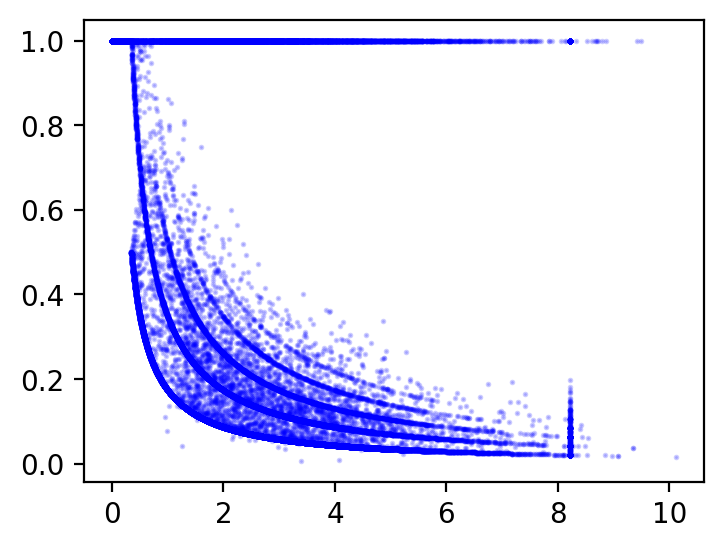

In [81]:
plt.figure(figsize=(4,3), dpi=200)
plt.scatter(mczip['KE'][:100000]*1e3, mczip['Yield'][:100000] / mczip['KE'][:100000], s = 1, color = 'blue', alpha = 0.2)

Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


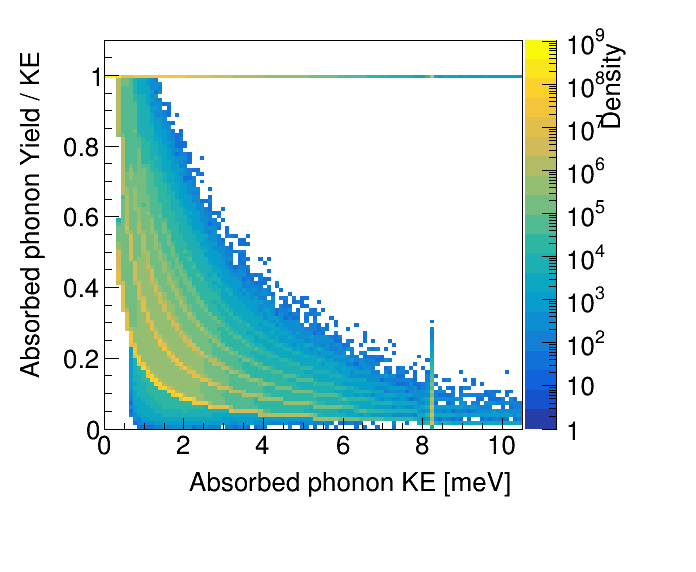

In [77]:
ROOT.gStyle.SetOptStat(0)
hist = ROOT.TH2F("h2", " ;Absorbed phonon KE [meV];Absorbed phonon Yield / KE; Density", 
                 100, 0, 10.5,
                 100, 0, 1.1)

for KE, y, weight in zip(mczip['KE'], mczip['Yield'], mczip['Weight']):
    hist.Fill(KE*1e3, y/KE, weight)

hist.GetXaxis().SetLabelSize(0.05)
hist.GetYaxis().SetLabelSize(0.05)
hist.GetZaxis().SetLabelSize(0.05)
hist.GetXaxis().SetTitleSize(0.05)
hist.GetXaxis().SetTitleOffset(1.2)
hist.GetYaxis().SetTitleSize(0.05)
hist.GetZaxis().SetTitleSize(0.05)
hist.SetMinimum(0)
c = ROOT.TCanvas("c", "c", 700, 600)
c.SetLeftMargin(0.15)
c.SetBottomMargin(0.25)
c.SetRightMargin(0.25)
c.SetTopMargin(0.07)

c.Update()  # needed so palette exists
palette = hist.GetListOfFunctions().FindObject("palette")
if palette:
    palette.SetTitleOffset(1.5)

hist.Draw("COLZ")
c.SetLogz()
c.Draw()

In [5]:
DMCfiles = np.sort(glob.glob('/scratch/perry/Ge71_Kshell_0V_100kEvents/DMCOutput/R?/Ge71_Kshell_????????_000???.root'))

In [6]:
# Sort by the last 3 characters
DMCfiles = sorted(DMCfiles, key=lambda s: float(s[-8:-5]))

In [7]:
g4dmcHits = CDataFrame('G4SimDir/g4dmcHits', DMCfiles)
EventNum = g4dmcHits.AsNumpy(['EventNum'])['EventNum']
X = g4dmcHits.AsNumpy(['X'])['X']*1e3
Y = g4dmcHits.AsNumpy(['Y'])['Y']*1e3
Z = g4dmcHits.AsNumpy(['Z'])['Z']*1e3

R = np.sqrt(X**2 + Y**2)

In [8]:
g4dmcEvent = CDataFrame('G4SimDir/g4dmcEvent', DMCfiles)
EventNum = g4dmcEvent.AsNumpy(['EventNum'])['EventNum']
PhononE = np.sum(g4dmcEvent.AsNumpy(['PhononE'])['PhononE']*1e-3, axis = 1)

In [3]:
RQfiles = np.sort(glob.glob("/scratch/perry/Ge71_Kshell_0V_100kEvents/Processed/R?/Unmerged/5125????_000000/Test_5125????_000000_F0???.root"))

In [4]:
det = 1 # detector number

df = CDataFrame("rqDir/zip"+str(det), RQfiles, friends = [[x+":rqDir/eventTree" for x in RQfiles]])

In [5]:
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(0), "PTOFamps>0"])

In [6]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQs = ["SeriesNumber", "EventNumber", "PTOFamps", "PTOFchisqLF"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels]
df_rqs = df_filtered.AsNumpy(RQs + ['EventTriggerID'])

In [7]:
def pt2keV(x):
    recoilE = x * calibFac
    return recoilE

In [8]:
calibFac = 7230000
df_rqs['PTOFamps_keVee'] = pt2keV(df_rqs['PTOFamps'])*10/4

In [19]:
K_peak_data = df_rqs['PTOFamps_keVee'][(df_rqs['PTOFamps_keVee'] >= 6) & (df_rqs['PTOFamps_keVee'] <= 16)]

 **********
 **   15 **SET PRINT           1
 **********
 **********
 **   16 **SET NOGRAD
 **********
 PARAMETER DEFINITIONS:
    NO.   NAME         VALUE      STEP SIZE      LIMITS
     1 #mu1         1.07500e+01  1.50000e-02    1.07000e+01  1.08500e+01
     2 #mu2         1.09000e+01  1.50000e-02    1.08500e+01  1.10000e+01
     3 #sigma1      1.00000e-01  2.40000e-02    1.00000e-02  2.50000e-01
     4 #sigma2      1.00000e-01  2.40000e-02    1.00000e-02  2.50000e-01
     5 c           -2.00000e+01  1.00000e+01   -1.00000e+02  0.00000e+00
     6 c1           4.30000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     7 c2           3.80000e-01  1.00000e-01    0.00000e+00  1.00000e+00
     8 m0           1.05000e+01  1.00000e-02    1.04500e+01  1.05500e+01
 **********
 **   17 **SET ERR         0.5
 **********
 **********
 **   18 **SET PRINT           1
 **********
 **********
 **   19 **SET STR           1
 **********
 NOW USING STRATEGY  1: TRY TO BALANCE SPEED AGAINST RELIABILITY
 

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


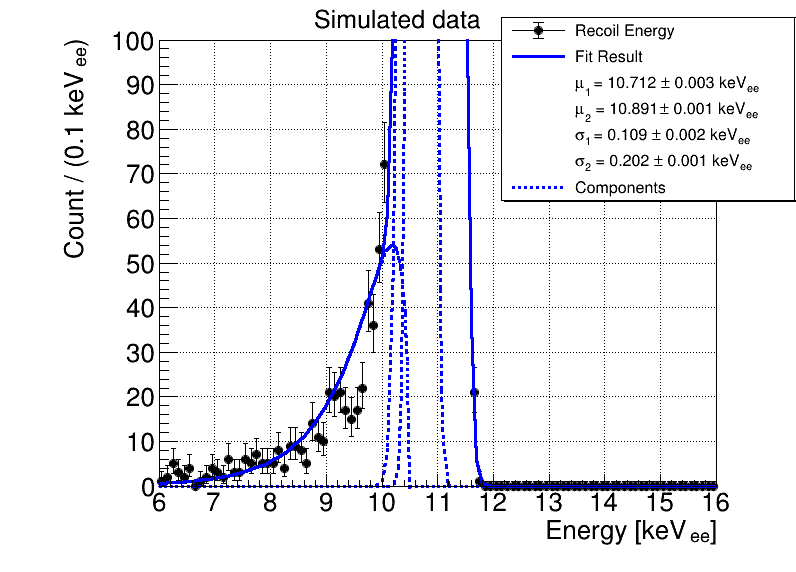

In [20]:
ROOT.gStyle.SetOptStat(0)
bins_start = 6
bins_end = 16
nbins = 100
bindiff = np.round((bins_end - bins_start) / nbins, 2)

# Create a ROOT histogram: (name, title, nbins, xmin, xmax)
h = ROOT.TH1F("h", ";Energy [keV_{ee}];Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})", nbins, bins_start, bins_end)
data = df_rqs['PTOFamps_keVee']

# Fill the histogram with data from the NumPy array
for value in data:
    h.Fill(value)

x = ROOT.RooRealVar("x", "x", bins_start, bins_end)  # use your histogram's x range

# Parameters
mean_1 = ROOT.RooRealVar("#mu1", "#mu", 10.75, 10.7, 10.85)
sigma_1 = ROOT.RooRealVar("#sigma1", "#sigma", 0.1, 0.01, 0.25)
mean_2 = ROOT.RooRealVar("#mu2", "#mu", 10.9, 10.85, 11)
sigma_2 = ROOT.RooRealVar("#sigma2", "#sigma", 0.1, 0.01, 0.25)

# Distributions
g1 = ROOT.RooGaussian("g1", "#g1", x, mean_1, sigma_1)
g2 = ROOT.RooGaussian("g2", "#g2", x, mean_2, sigma_2)

# Argus background (left-side tail)
m0   = ROOT.RooRealVar("m0", "Endpoint", 10.5, 10.45, 10.55)  # same as Gaussian mean
c    = ROOT.RooRealVar("c", "Curvature", -20.0, -100.0, 0.0)
argus = ROOT.RooArgusBG("argus", "Argus Tail", x, m0, c)

# Weight of distributions
frac1 = ROOT.RooRealVar("c1", "#c", 0.43, 0.0, 1.0)
frac2 = ROOT.RooRealVar("c2", "#c", 0.38, 0.0, 1.0)
frac3 = ROOT.RooRealVar("c3", "#c", 0.05, 0.0, 0.2)
#frac4 = ROOT.RooRealVar("c4", "#c", 0.15, 0.0, 1.0)

# Convert numpy array into RooFit object
model = ROOT.RooAddPdf("model", "model", ROOT.RooArgList(g1, g2, argus), ROOT.RooArgList(frac1, frac2))
data = ROOT.RooDataHist("data", "binned data", ROOT.RooArgList(x), h)

#fit_result = model.fitTo(data)  # binned by default for RooDataHist
nll = model.createNLL(data)
m = ROOT.RooMinimizer(nll)
m.migrad()

fit_result = m.save()

frame = x.frame(ROOT.RooFit.Title("Simulated data"))
frame.SetLabelSize(0.05)
# Change axis labels
frame.GetXaxis().SetTitle("Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]")
frame.GetYaxis().SetTitle(f"Count / (" + str(bindiff) + " keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}})")
frame.GetXaxis().SetLabelSize(0.05)
frame.GetYaxis().SetLabelSize(0.05)
frame.GetXaxis().SetTitleSize(0.05)
frame.GetYaxis().SetTitleSize(0.05)

data.plotOn(frame, ROOT.RooFit.Name("Recoil Energy"))
model.plotOn(frame, ROOT.RooFit.Name(f"Fit Result"))
model.plotOn(frame, ROOT.RooFit.Components("g1"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue), ROOT.RooFit.Name("Components"))
model.plotOn(frame, ROOT.RooFit.Components("g2"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))
model.plotOn(frame, ROOT.RooFit.Components("argus"), ROOT.RooFit.LineStyle(ROOT.kDashed), ROOT.RooFit.LineColor(ROOT.kBlue))

#upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_2, sigma_2))
#lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_1, sigma_1))
#mean_upper_bound = upper_bound.getVal()
#mean_lower_bound = lower_bound.getVal()
#x.setRange("gaussRange", bins_start, mean_upper_bound)

#frame_narrow = x.frame(ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Title("Narrow"))

# Plot data and model within the narrow range
#data.plotOn(frame_narrow, ROOT.RooFit.Range("gaussRange"), ROOT.RooFit.Name("data_narrow"))
#model.plotOn(frame_narrow,
#             ROOT.RooFit.Range("gaussRange"),
#             ROOT.RooFit.Name("model_narrow"))
#chi2_narrow = frame_narrow.chiSquare(8)

# Create legend
legend = ROOT.TLegend(0.63, 0.65, 1, 0.97)
legend.SetBorderSize(2)
legend.SetFillColor(0)

# Add entries by retrieving plotted objects by name
legend.AddEntry(frame.findObject("Recoil Energy"),  "Recoil Energy", "lep")
legend.AddEntry(frame.findObject(f"Fit Result"), f"Fit Result", "l")
legend.AddEntry(0, "#mu_{1} = " + f"{mean_1.getVal():.3f} #pm {mean_1.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#mu_{2} = " + f"{mean_2.getVal():.3f} #pm {mean_2.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma_{1} = " + f"{sigma_1.getVal():.3f} #pm {sigma_1.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
legend.AddEntry(0, "#sigma_{2} = " + f"{sigma_2.getVal():.3f} #pm {sigma_2.getPropagatedError(fit_result):.3f}" + " keV_{ee}", "")
#legend.AddEntry(0, "#chi^{2} / ndof = " + f"{chi2_narrow:.2f}", "")
legend.AddEntry(frame.findObject("Components"), "Components", "l")
legend.SetTextSize(0.03)

frame.SetMinimum(0)
#frame.SetMaximum(20000)  # Adjust based on your data
frame.SetMaximum(100)  # Adjust based on your data
    
c = ROOT.TCanvas("c", "Fit Canvas", 800, 600)
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.15)
c.SetRightMargin(0.1)
c.SetTopMargin(0.07)
c.SetGrid(1, 1)
frame.Draw()
legend.Draw()
c.Draw()

In [26]:
upper_bound = ROOT.RooFormulaVar("upperBound", "@0 + 3 * @1", ROOT.RooArgList(mean_2, sigma_2))
lower_bound = ROOT.RooFormulaVar("lowerBound", "@0 - 3 * @1", ROOT.RooArgList(mean_2, sigma_2))

mean_upper_bound = upper_bound.getVal()
err_upper_bound = upper_bound.getPropagatedError(fit_result)
mean_lower_bound = lower_bound.getVal()
err_lower_bound = lower_bound.getPropagatedError(fit_result)

print('The range of the peak is ' + str_with_err(mean_lower_bound, err_lower_bound) + ' keV to ' + str_with_err(mean_upper_bound, err_upper_bound) + ' keV')

rangeCut = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound)
rangeCut_max = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound - err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound + err_upper_bound)
rangeCut_min = (df_rqs['PTOFamps_keVee'] >= mean_lower_bound + err_lower_bound) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound - err_upper_bound)

count = sum(rangeCut)
count_stat = np.sqrt(count)
count_variation = np.mean([abs(count - sum(rangeCut_min)), abs(count - sum(rangeCut_max))])
count_err = np.sqrt( count_stat**2 + count_variation**2 )

print('The number of events inside the peak range is ' + str(round(count, 2)) + ' +/- ' + str(round(count_err, 2)))

The range of the peak is 10.283(3) keV to 11.498(2) keV
The number of events inside the peak range is 99066 +/- 314.8


In [27]:
nevent_window = sum((df_rqs['PTOFamps_keVee'] >= bins_start) & (df_rqs['PTOFamps_keVee'] <= mean_upper_bound))

# signal events in peak
print('The fraction of signal events in the peak is ' + str(round(count / nevent_window * 100, 2)) + ' +/- ' + str(round(count_err / nevent_window * 100, 3)))

# signal events below peak
signal_tail = nevent_window - count
signal_tail_err = count_err
print('The fraction of signal events in the tail is ' + str(round(signal_tail / nevent_window * 100, 2)) + ' +/- ' + str(round(signal_tail_err / nevent_window * 100, 2)))

# non-peak signal to peak signal
ratio = signal_tail / count
ratio_err = np.sqrt( (signal_tail_err / count)**2 + (signal_tail / count**2 * count_err)**2)
print('The ratio of non-peak signal to peak signal is ' + str(round(ratio, 3)) + ' +/- ' + str(round(ratio_err, 3)))

The fraction of signal events in the peak is 99.23 +/- 0.315
The fraction of signal events in the tail is 0.77 +/- 0.32
The ratio of non-peak signal to peak signal is 0.008 +/- 0.003


In [28]:
ufloat(0.018, 0.083) / ufloat(0.008, 0.003)

2.25+/-10.409252569829402